In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

%matplotlib inline
sns.set(style='whitegrid')

current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}\n")

Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)



## Feature Engineering

In [31]:
def feature_engineering(df, is_train=True, q_stats=None, dt_bins=None, global_mean=None):
    df_fe = df.copy()
    
    if is_train:
        # 1. Target Encoding: Trung bình giá 1m2 theo khu vực
        df_fe['gia_m2'] = df_fe['gia'] / df_fe['dien_tich_dat']
        q_stats = df_fe.groupby('quan')['gia_m2'].mean().to_dict()
        global_mean = df_fe['gia_m2'].mean()
        
        df_fe['gia_m2_tb_quan'] = df_fe['quan'].map(q_stats)
        df_fe['gia_m2_tb_quan'] = df_fe['gia_m2_tb_quan'].fillna(global_mean)
        df_fe['gia_m2_tb_quan_log'] = np.log(df_fe['gia_m2_tb_quan'])
        
        # 2. Phân Diện tích đất ra thành 4 Bins (Quartiles - Q1, Q2, Q3)
        _, dt_bins = pd.qcut(df_fe['dien_tich_dat'], q=4, retbins=True)
        # Nới rộng biên để chắc chắn chứa mọi giá trị ngoại lệ của tập Test
        dt_bins[0] = -np.inf
        dt_bins[-1] = np.inf
        
        df_fe['nhom_dien_tich'] = pd.cut(df_fe['dien_tich_dat'], bins=dt_bins, labels=['DT_Nho', 'DT_TrungBinh', 'DT_Kha', 'DT_Lon'])
        
        # 3. Tạo biến tương tác (Sự cộng hưởng giữa Diện tích và Vị trí)
        df_fe['tuong_tac_dt_vt'] = df_fe['dien_tich_log'] * df_fe['gia_m2_tb_quan_log']
        
        return df_fe, q_stats, dt_bins, global_mean
    else:
        # Áp dụng tập luật từ Train sang tập Test
        df_fe['gia_m2_tb_quan'] = df_fe['quan'].map(q_stats)
        df_fe['gia_m2_tb_quan'] = df_fe['gia_m2_tb_quan'].fillna(global_mean)
        df_fe['gia_m2_tb_quan_log'] = np.log(df_fe['gia_m2_tb_quan'])
        
        # Dùng lại dt_bins từ Train để chia nhóm cho tập Test
        df_fe['nhom_dien_tich'] = pd.cut(df_fe['dien_tich_dat'], bins=dt_bins, labels=['DT_Nho', 'DT_TrungBinh', 'DT_Kha', 'DT_Lon'])
        
        df_fe['tuong_tac_dt_vt'] = df_fe['dien_tich_log'] * df_fe['gia_m2_tb_quan_log']
        
        return df_fe

# Triển khai hàm
X_train_fe, quan_means_map, train_dt_bins, train_global_mean = feature_engineering(train_df, is_train=True)
X_test_fe = feature_engineering(test_df, is_train=False, q_stats=quan_means_map, dt_bins=train_dt_bins, global_mean=train_global_mean)
print("Đã thiết kế đặc trưng thành công!\n")

Đã thiết kế đặc trưng thành công!



# CHUẨN BỊ DỮ LIỆU & ONE-HOT ENCODING

In [32]:
features = ['dien_tich_log', 'phong_tam', 'so_tang', 'gia_m2_tb_quan_log', 'tuong_tac_dt_vt', 'nhom_dien_tich', 'phap_ly']

X_train_raw = X_train_fe[features]
y_train = X_train_fe['gia_log']  

X_test_raw = X_test_fe[features]
y_test_original = test_df['gia']  
y_test_log = test_df['gia_log']

# Mã hóa One-hot cho Pháp lý và Nhóm diện tích (bắt buộc drop_first=True với Linear Regression)
X_train = pd.get_dummies(X_train_raw, columns=['phap_ly', 'nhom_dien_tich'], drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=['phap_ly', 'nhom_dien_tich'], drop_first=True)

# Đồng bộ cột giữa Train và Test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 4. HUẤN LUYỆN MÔ HÌNH LINEAR REGRESSION

In [33]:
# Khởi tạo và Huấn luyện OLS truyền thống
model_2 = LinearRegression()
model_2.fit(X_train, y_train)

print(f"--- MODEL 2: HUẤN LUYỆN HOÀN TẤT ---")
print(f"Hệ số chặn (Intercept): {model_2.intercept_:.4f}")
for col, coef in zip(X_train.columns, model_2.coef_):
    print(f"  > {col}: {coef:.4f}")

--- MODEL 2: HUẤN LUYỆN HOÀN TẤT ---
Hệ số chặn (Intercept): -2.8314
  > dien_tich_log: 1.3932
  > phong_tam: 0.0389
  > so_tang: 0.0670
  > gia_m2_tb_quan_log: -0.9191
  > tuong_tac_dt_vt: 0.3738
  > phap_ly_Đã có sổ: 0.1801
  > nhom_dien_tich_DT_TrungBinh: -0.0328
  > nhom_dien_tich_DT_Kha: -0.0502
  > nhom_dien_tich_DT_Lon: -0.0385


# 5. DỰ ĐOÁN & CHỈ SỐ ĐÁNH GIÁ (METRICS)

In [34]:
y_pred_log = model_2.predict(X_test)
y_pred_original = np.expm1(y_pred_log)

r2 = r2_score(y_test_log, y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

results_m2 = pd.DataFrame({
    'Metric': ['R-squared (R2)', 'MAE (Tỷ VNĐ)', 'MSE', 'RMSE (Tỷ VNĐ)'],
    'Value': [f"{r2:.4f}", f"{mae:.4f}", f"{mse:.4f}", f"{rmse:.4f}"]
})
print("--- HIỆU SUẤT MÔ HÌNH 2 (T.Loi) ---")
display(results_m2)

--- HIỆU SUẤT MÔ HÌNH 2 (T.Loi) ---


,Metric,Value
0,R-squared (R2),0.7295
1,MAE (Tỷ VNĐ),2.7640
2,MSE,27.5220
3,RMSE (Tỷ VNĐ),5.2461


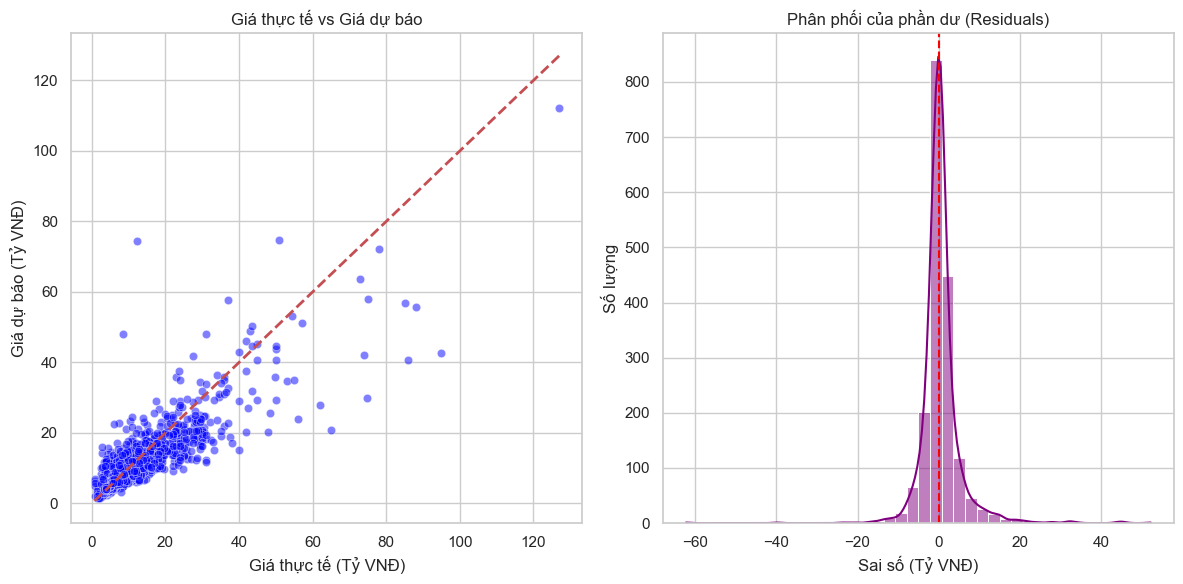

In [35]:
plt.figure(figsize=(12, 6))

residuals = y_test_original - y_pred_original

# --- HÌNH 1: Scatter Plot Giá Thực vs Giá Dự Báo ---
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5, color='blue')
min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.title("Giá thực tế vs Giá dự báo")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự báo (Tỷ VNĐ)")

# --- HÌNH 2: Phân phối Phần dư (Residuals) ---
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple', bins=40)
plt.axvline(0, color='red', linestyle='--')

plt.title("Phân phối của phần dư (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")
plt.ylabel("Số lượng")

plt.tight_layout()
plt.show()